## makemore: becoming a backprop ninja

swole doge style

In [1]:
# 前面几个单元格和上一课一样（导入库、读数据、建字符表、建数据集），没有变化

In [ ]:
import torch  # 导入 PyTorch
import torch.nn.functional as F  # 函数库
import matplotlib.pyplot as plt # 画图库
# %matplotlib inline  # 图直接显示在 notebook 里

In [3]:
# 读取所有人名
words = open('names.txt', 'r').read().splitlines()  # 打开文件按行读成列表
print(len(words))  # 打印名字总数
print(max(len(w) for w in words))  # 打印最长名字的长度
print(words[:8])  # 打印前 8 个名字

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# 建立【字符表】以及“字符 <-> 数字”映射
chars = sorted(list(set(''.join(words))))  # 拼串、去重、排序
stoi = {s:i+1 for i,s in enumerate(chars)}  # 字符→数字，编号从 1 开始
stoi['.'] = 0  # '.' 编号 0
itos = {i:s for s,i in stoi.items()}  # 数字→字符（反向）
vocab_size = len(itos)  # 词表大小
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# 构建数据集（和前几课一样的“滑动窗口”逻辑）
block_size = 3 # 上下文长度：用前 3 个字符预测下一个

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size  # 初始窗口全 0
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)  # 输入：当前窗口
      Y.append(ix)  # 输出：下一个字符
      context = context[1:] + [ix] # 窗口右滑一格

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 训练集 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 验证集 10%
Xte,  Yte  = build_dataset(words[n2:])     # 测试集 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# 前面的准备工作完成，现在进入正题：

In [7]:
# 工具函数：比较“手动算的梯度 dt”和“PyTorch 自动算的梯度 t.grad”，看是否一致
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()  # 是否完全相同（精确相等）
  app = torch.allclose(dt, t.grad)  # 是否近似相等（允许极小浮点误差）
  maxdiff = (dt - t.grad).abs().max().item()  # 两者的最大误差
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [8]:
n_embd = 10 # 嵌入向量维度（每个字符用 10 个数字描述）
n_hidden = 64 # 隐藏层神经元个数

g = torch.Generator().manual_seed(2147483647) # 固定随机种子
C  = torch.randn((vocab_size, n_embd),            generator=g)  # 嵌入表
# 第一层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)  # 第一层权重（乘 5/3/sqrt 缩放初始化）
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # 第一层偏置（因为后面有批归一化，这个偏置其实没用，纯演示）
# 第二层
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1  # 第二层权重
b2 = torch.randn(vocab_size,                      generator=g) * 0.1  # 第二层偏置
# 批归一化参数
bngain = torch.randn((1, n_hidden))*0.1 + 1.0  # 缩放参数 gamma（初始接近 1）
bnbias = torch.randn((1, n_hidden))*0.1  # 平移参数 beta（初始接近 0）

# 注意：这里故意用“非标准”的方式初始化一些参数，
# 因为如果用全 0 之类的方式初始化，可能会掩盖反向传播实现里的错误。

parameters = [C, W1, b1, W2, b2, bngain, bnbias]  # 所有需要训练的参数
print(sum(p.nelement() for p in parameters)) # 打印参数总数
for p in parameters:
  p.requires_grad = True  # 让每个参数都计算梯度

4137


In [9]:
batch_size = 32
n = batch_size # 简写变量，方便后面用
# 构造一个小批量
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)  # 随机挑 32 个行号
Xb, Yb = Xtr[ix], Ytr[ix] # 取出本批的输入 Xb 和答案 Yb

In [10]:
# 前向传播，故意“拆碎”成很多小步骤，这样每一步都能单独做反向传播

emb = C[Xb] # 字符查表变嵌入向量
embcat = emb.view(emb.shape[0], -1) # 把 3 个字符的向量拼接成一条长向量
# 线性层 1
hprebn = embcat @ W1 + b1 # 隐藏层“激活前”的数值
# 批归一化层（这里手动拆开每一步）
bnmeani = 1/n*hprebn.sum(0, keepdim=True)  # 均值 = 求和 / n
bndiff = hprebn - bnmeani  # 每个数减去均值
bndiff2 = bndiff**2  # 平方
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # 方差（注意除以 n-1 而不是 n，叫贝塞尔校正）
bnvar_inv = (bnvar + 1e-5)**-0.5  # 标准差的倒数（1e-5 防止除零）
bnraw = bndiff * bnvar_inv  # 标准化后的值
hpreact = bngain * bnraw + bnbias  # 再用 gamma/beta 缩放平移
# 非线性激活
h = torch.tanh(hpreact) # 隐藏层输出
# 线性层 2
logits = h @ W2 + b2 # 输出层
# 交叉熵损失（等价于 F.cross_entropy(logits, Yb)，这里手动拆开每一步）
logit_maxes = logits.max(1, keepdim=True).values  # 每行最大值
norm_logits = logits - logit_maxes # 减最大值（数值稳定性技巧）
counts = norm_logits.exp()  # 取指数
counts_sum = counts.sum(1, keepdims=True)  # 每行求和
counts_sum_inv = counts_sum**-1 # 倒数（用 **-1 而不是 1/ 是为了让反向传播能精确对齐）
probs = counts * counts_sum_inv  # 概率
logprobs = probs.log()  # 取对数
loss = -logprobs[range(n), Yb].mean()  # 负对数似然的平均 = 损失

# 用 PyTorch 自动做反向传播（作为“标准答案”，供后面手动结果对比）
for p in parameters:
  p.grad = None  # 清零梯度
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # 把这些中间变量都保留梯度（似乎没有更简洁的办法）
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()  # retain_grad 保留中间变量的梯度
loss.backward()  # 自动反向传播
loss

tensor(3.3377, grad_fn=<NegBackward0>)

In [210]:
# 练习 1：手动把整个网络反向传播一遍，
# 严格按照前向传播里定义的每一个变量，逐个反推它们的梯度

dlogprobs = torch.zeros_like(logprobs)  # 损失对 logprobs 的梯度，初始全 0
dlogprobs[range(n), Yb] = -1.0/n  # 正确位置设为 -1/n（因为 loss = 对正确项取负再平均）
dprobs = (1.0 / probs) * dlogprobs  # 反向：d(log(x))/dx = 1/x
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)  # 反向：probs = counts * counts_sum_inv
dcounts = counts_sum_inv * dprobs  # 反向：乘法的链式法则
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv  # 反向：counts_sum_inv = counts_sum**-1
dcounts += torch.ones_like(counts) * dcounts_sum  # 反向：counts_sum = counts 求和
dnorm_logits = counts * dcounts  # 反向：counts = norm_logits.exp()，d(exp)/dx = exp(x)
dlogits = dnorm_logits.clone()  # 反向：norm_logits = logits - logit_maxes
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)  # 反向：减最大值的梯度
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes  # 把 max 的梯度传回对应位置
dh = dlogits @ W2.T  # 反向：logits = h @ W2
dW2 = h.T @ dlogits  # 反向：W2 的梯度
db2 = dlogits.sum(0)  # 反向：b2 的梯度
dhpreact = (1.0 - h**2) * dh  # 反向：h = tanh(hpreact)，d(tanh)/dx = 1 - tanh^2
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)  # 反向：bngain 的梯度
dbnraw = bngain * dhpreact  # 反向：hpreact = bngain * bnraw + bnbias
dbnbias = dhpreact.sum(0, keepdim=True)  # 反向：bnbias 的梯度
dbndiff = bnvar_inv * dbnraw  # 反向：bnraw = bndiff * bnvar_inv
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)  # 反向
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv  # 反向：bnvar_inv = (bnvar + 1e-5)**-0.5
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar  # 反向：bnvar = 1/(n-1)*sum(bndiff2)
dbndiff += (2*bndiff) * dbndiff2  # 反向：bndiff2 = bndiff**2
dhprebn = dbndiff.clone()  # 反向：bndiff = hprebn - bnmeani
dbnmeani = (-dbndiff).sum(0)  # 反向：减均值的梯度
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)  # 反向：bnmeani = 1/n * sum
dembcat = dhprebn @ W1.T  # 反向：hprebn = embcat @ W1 + b1
dW1 = embcat.T @ dhprebn  # 反向：W1 的梯度
db1 = dhprebn.sum(0)  # 反向：b1 的梯度
demb = dembcat.view(emb.shape)  # 反向：embcat = emb.view(...)
dC = torch.zeros_like(C)  # C 的梯度初始为 0
for k in range(Xb.shape[0]):  # 因为 emb = C[Xb] 是“查表”操作，需要把梯度累加回每个字符对应的行
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]  # 把该位置字符的梯度累加到 C 的对应行

# 下面逐项对比：手动梯度 vs PyTorch 自动梯度
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [211]:
# 练习 2：把交叉熵的反向传播一步到位（不再拆成很多小步）
# 做法：直接看损失函数的数学表达式，求导、化简，然后直接写出来

# 前向传播

# 之前（拆碎版）：
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# 现在（一步到位版）：
loss_fast = F.cross_entropy(logits, Yb)  # 直接用现成的交叉熵函数
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())  # 打印与拆碎版结果的差异（应几乎为 0）

3.3377387523651123 diff: 2.384185791015625e-07


In [229]:
# 反向传播（一步到位版）

dlogits = F.softmax(logits, 1)  # softmax 的概率（这就是梯度主体）
dlogits[range(n), Yb] -= 1  # 正确位置减 1
dlogits /= n  # 除以 n（因为损失取了平均）

cmp('logits', dlogits, logits) # 只能近似相等，最大误差约 6e-9（浮点误差）

logits          | exact: False | approximate: True  | maxdiff: 5.122274160385132e-09


In [225]:
logits.shape, Yb.shape  # 查看形状

(torch.Size([32, 27]), torch.Size([32]))

In [235]:
F.softmax(logits, 1)[0]  # 显示第一条样本的 softmax 概率分布

tensor([0.0719, 0.0881, 0.0193, 0.0493, 0.0169, 0.0864, 0.0226, 0.0356, 0.0165,
        0.0314, 0.0364, 0.0383, 0.0424, 0.0279, 0.0317, 0.0142, 0.0085, 0.0195,
        0.0152, 0.0555, 0.0450, 0.0236, 0.0250, 0.0662, 0.0616, 0.0269, 0.0239],
       grad_fn=<SelectBackward0>)

In [234]:
dlogits[0] * n  # 显示第一条样本的梯度乘 n（应该等于 softmax 概率减去 one-hot 向量）

tensor([ 0.0719,  0.0881,  0.0193,  0.0493,  0.0169,  0.0864,  0.0226,  0.0356,
        -0.9835,  0.0314,  0.0364,  0.0383,  0.0424,  0.0279,  0.0317,  0.0142,
         0.0085,  0.0195,  0.0152,  0.0555,  0.0450,  0.0236,  0.0250,  0.0662,
         0.0616,  0.0269,  0.0239], grad_fn=<MulBackward0>)

In [238]:
dlogits[0].sum()  # 验证梯度这一行求和应接近 0

tensor(1.3970e-09, grad_fn=<SumBackward0>)

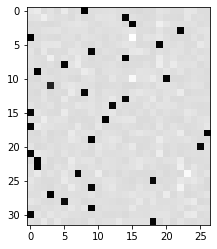

In [239]:
plt.figure(figsize=(4, 4))  # 画布大小
plt.imshow(dlogits.detach(), cmap='gray')  # 把梯度矩阵画成灰度图（detach 表示脱离计算图，只取数值）

In [269]:
# 练习 3：把批归一化的反向传播一步到位
# 做法：看批归一化输出的数学表达式，对输入求导、化简，直接写出来

# 前向传播

# 之前（拆碎版）：
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# 现在（一步到位版）：
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())  # 打印最大差异（应接近 0）

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [279]:
# 反向传播

# 之前（拆碎版）：
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# 现在（一步到位版）：给定 dhpreact，算出 dhprebn（即反向穿过批归一化）
# （需要用到前向传播里的一些变量）

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # 只能近似相等，最大误差约 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [278]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape  # 查看各张量形状，帮助推导公式

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [286]:
# 练习 4：把所有东西合起来！
# 用你自己写的手动反向传播来训练这个 MLP 网络

# 初始化
n_embd = 10 # 嵌入向量维度
n_hidden = 200 # 隐藏层神经元个数

g = torch.Generator().manual_seed(2147483647) # 固定随机种子
C  = torch.randn((vocab_size, n_embd),            generator=g)  # 嵌入表
# 第一层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)  # 第一层权重
b1 = torch.randn(n_hidden,                        generator=g) * 0.1  # 第一层偏置
# 第二层
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1  # 第二层权重
b2 = torch.randn(vocab_size,                      generator=g) * 0.1  # 第二层偏置
# 批归一化参数
bngain = torch.randn((1, n_hidden))*0.1 + 1.0  # 缩放 gamma
bnbias = torch.randn((1, n_hidden))*0.1  # 平移 beta

parameters = [C, W1, b1, W2, b2, bngain, bnbias]  # 所有参数
print(sum(p.nelement() for p in parameters))  # 参数总数
for p in parameters:
  p.requires_grad = True

# 和之前一样的优化流程
max_steps = 200000  # 最多 20 万步
batch_size = 32
n = batch_size # 简写
lossi = []  # 记录损失

# 用 no_grad 上下文管理器提升效率（因为不用 PyTorch 自动求导了）
with torch.no_grad():

  # 开始优化
  for i in range(max_steps):

    # 构造小批量
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # 前向传播
    emb = C[Xb]  # 查表
    embcat = emb.view(emb.shape[0], -1)  # 拼接
    # 线性层
    hprebn = embcat @ W1 + b1
    # 批归一化层
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # 非线性激活
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # 反向传播（手动！不用 loss.backward()）
    for p in parameters:
      p.grad = None
    #loss.backward() # （被注释）用来做正确性对比，之后删除

    # 手动反向传播！
    # -----------------
    dlogits = F.softmax(logits, 1)  # 交叉熵 + softmax 合并的梯度
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 第二层反向
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh 反向
    dhpreact = (1.0 - h**2) * dh
    # 批归一化反向
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 第一层反向
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # 嵌入层反向
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # 更新参数
    lr = 0.1 if i < 100000 else 0.01 # 学习率衰减
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # 旧方式（用 PyTorch 自动梯度）
      p.data += -lr * grad # 新方式（用手动梯度）

    # 记录状态
    if i % 10000 == 0:
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

  #   if i >= 100: # TODO: 准备好训练完整网络时删除这个提前 break
  #     break

12297
      0/ 200000: 3.7805
  10000/ 200000: 2.1775
  20000/ 200000: 2.3957
  30000/ 200000: 2.5032
  40000/ 200000: 2.0065
  50000/ 200000: 2.3873
  60000/ 200000: 2.3378
  70000/ 200000: 2.0640
  80000/ 200000: 2.3497
  90000/ 200000: 2.1093
 100000/ 200000: 1.9132
 110000/ 200000: 2.2229
 120000/ 200000: 1.9912
 130000/ 200000: 2.4441
 140000/ 200000: 2.3198
 150000/ 200000: 2.1857
 160000/ 200000: 2.0296
 170000/ 200000: 1.8391
 180000/ 200000: 2.0436
 190000/ 200000: 1.9200


In [285]:
# 检查梯度的辅助代码（被注释，需要时可取消注释）
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [299]:
# 训练结束后，用整个训练集重新测量均值和方差，作为“最终校准”值
with torch.no_grad():
  # 把训练集跑一遍前向（到批归一化之前）
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # 在整个训练集上测均值和方差
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [300]:
# 评估训练集和验证集的损失

@torch.no_grad() # 这个装饰器：不追踪梯度
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]  # 根据名字选数据集
  emb = C[x]  # 查表
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias  # 用训练时保存的均值/方差做标准化
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')  # 训练集损失
split_loss('val')  # 验证集损失

train 2.070523500442505
val 2.109893560409546


In [294]:
# 我得到的（结果记录）：
# train 2.0718822479248047
# val 2.1162495613098145

In [301]:
# 从模型采样生成名字
g = torch.Generator().manual_seed(2147483647 + 10)  # 固定随机种子

for _ in range(20):  # 生成 20 个名字

    out = []
    context = [0] * block_size # 初始上下文全 0
    while True:
      # ------------
      # 前向传播：
      # 嵌入
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias  # 用校准的均值/方差
      h = torch.tanh(hpreact)
      logits = h @ W2 + b2
      # ------------
      # 采样
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))  # 解码打印名字

carmahzamille.
khi.
mreigeet.
khalaysie.
mahnen.
delynn.
jareen.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinn.
shoison.
jadiquintero.
dearyxi.
jace.
pinsley.
dae.
iia.
